<a href="https://colab.research.google.com/github/BhargaviPS/BhargaviPS/blob/main/DMSassignment29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Successfully found and loading: titanic_train_7f3cbe37-c2fb-49a8-861a-91ced5fa1d6e.csv

Dataset Head:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3     

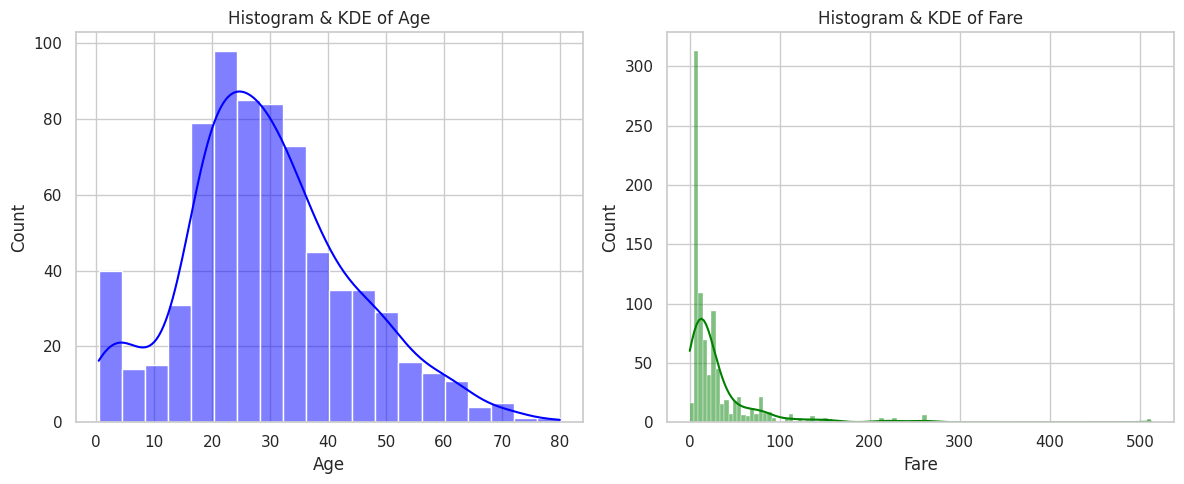

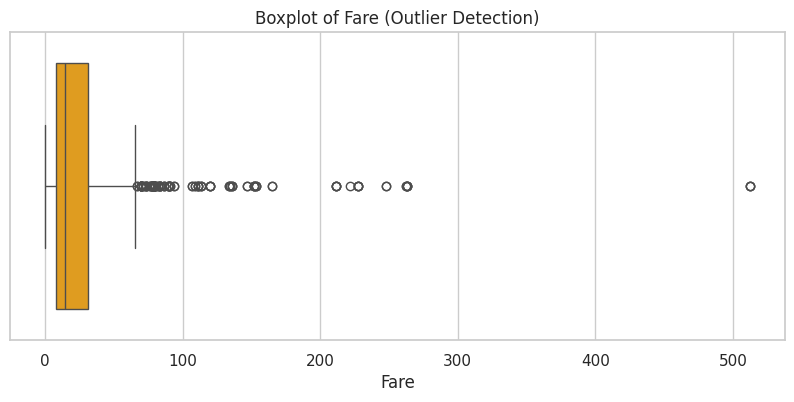

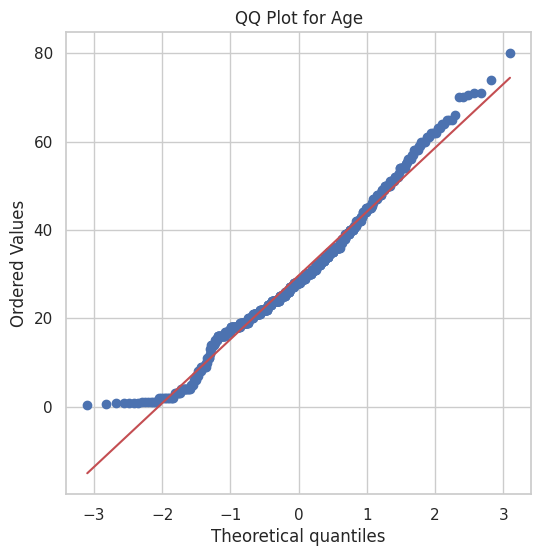

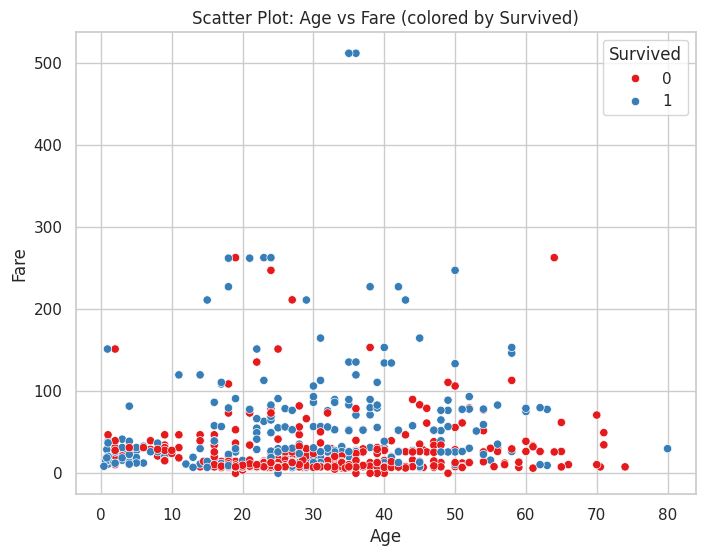



PART 3: Exploratory Data Analysis for Survival Factors

Survival Rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


Survival Rate by Passenger Class (Pclass):
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64




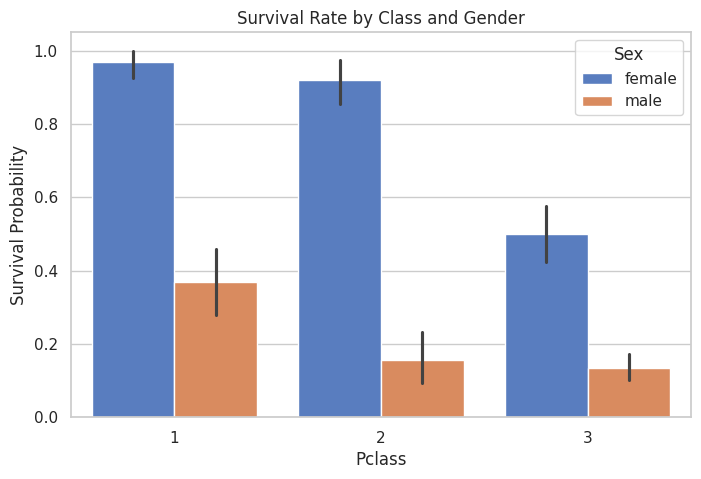



PART 4: Data Preprocessing and Cleaning

Missing Values Before Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Has_Cabin      0
Embarked_Q     0
Embarked_S     0
dtype: int64

Cleaned Data Head:
   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Has_Cabin  \
0            1         0       3    0  22.0      1      0   7.2500          0   
1            2         1       1    1  38.0      1      0  71.2833          1   
2            3         1       3    1  26.0      0      0   7.9250          0   
3            4         1       1    1  35.0      1      0  53.1000          1   
4            5         0  

In [ ]:
import glob
import pandas as pd


csv_files = glob.glob("titanic*.csv")

if csv_files:
  file_name = csv_files[0]
  print(f"Successfully found and loading: {file_name}")
  df = pd.read_csv(file_name)
else:
  print("No CSV file found. Please upload it using the prompt below:")
  from google.colab import files

  uploaded = files.upload()
  file_name = list(uploaded.keys())[0]
  df = pd.read_csv(file_name)

print("\nDataset Head:")
print(df.head())
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")



print("--- Dataset Head ---")
print(df.head())
print("\n" + "=" * 50 + "\n")


print("PART 1: Attribute Analysis, Types, Distinct Values, and Statistics\n")

# Data types and non-null counts
print("Data Types & Non-Null Counts:")
print(df.info())
print("\n")

# Distinct values per attribute
print("Distinct Values per Attribute:")
print(df.nunique())
print("\n")

# Mean, Median, Standard Deviation, and Range for numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
stats_summary = pd.DataFrame(
    {
        "Mean": df[num_cols].mean(),
        "Median": df[num_cols].median(),
        "Std Dev": df[num_cols].std(),
        "Min": df[num_cols].min(),
        "Max": df[num_cols].max(),
    }
)
stats_summary["Range"] = stats_summary["Max"] - stats_summary["Min"]
print("Descriptive Statistics (Mean, Median, Std, Range):")
print(stats_summary)
print("\n" + "=" * 50 + "\n")


print("PART 2: Creating Plots and Checking Distributions\n")

# Histograms and KDE for Numerical Distributions (e.g., Age and Fare)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["Age"].dropna(), kde=True, color="blue")
plt.title("Histogram & KDE of Age")

plt.subplot(1, 2, 2)
sns.histplot(df["Fare"], kde=True, color="green")
plt.title("Histogram & KDE of Fare")

plt.tight_layout()
plt.show()

# Boxplots for Outlier Detection
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Fare"], color="orange")
plt.title("Boxplot of Fare (Outlier Detection)")
plt.show()

# QQ Plot to check normality of Age
plt.figure(figsize=(6, 6))
stats.probplot(df["Age"].dropna(), dist="norm", plot=plt)
plt.title("QQ Plot for Age")
plt.show()

#  Scatter Plot between Age and Fare colored by Survived
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", palette="Set1")
plt.title("Scatter Plot: Age vs Fare (colored by Survived)")
plt.show()

print("\n" + "=" * 50 + "\n")



print("PART 3: Exploratory Data Analysis for Survival Factors\n")

# Survival rate by Sex
print("Survival Rate by Sex:")
print(df.groupby("Sex")["Survived"].mean())
print("\n")

# Survival rate by Pclass (Passenger Class)
print("Survival Rate by Passenger Class (Pclass):")
print(df.groupby("Pclass")["Survived"].mean())
print("\n")

# Visualization of Survival by Pclass and Sex
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex", palette="muted")
plt.title("Survival Rate by Class and Gender")
plt.ylabel("Survival Probability")
plt.show()

print("\n" + "=" * 50 + "\n")



print("PART 4: Data Preprocessing and Cleaning\n")

# Check missing values before cleaning
print("Missing Values Before Cleaning:")
print(df.isnull().sum())
print("\n")

#  Impute missing 'Age' with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

#  Handle 'Embarked' missing values by filling with the mode (most common value)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

#  Drop 'Cabin' column due to excessive missing values, or create a binary indicator
df["Has_Cabin"] = df["Cabin"].notnull().astype(int)
df = df.drop(columns=["Cabin", "Ticket", "Name"])

#  Encode categorical variables ('Sex' and 'Embarked')
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Check missing values and data shape after cleaning
print("Missing Values After Cleaning:")
print(df.isnull().sum())
print("\nCleaned Data Head:")
print(df.head())

1st and 2nd class female passengers have most chance of survival.